In [58]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
import seaborn as sns
import random
from skimage.transform import resize
from biosonic.handle import read_wav
from biosonic.compute.utils import extract_all_features
from biosonic.compute.spectrotemporal import spectrogram, cepstral_coefficients, tokuda_nlm
from biosonic.plot import plot_spectrogram

from joblib import Parallel, delayed

In [59]:
DATAPATH = "/Users/lena/Desktop/Master/Thesis/geese/code/WorkshpTim/bfsongrepo/"
track_paths = glob.glob(DATAPATH+"**/**/*.wav")
print(len(track_paths))

3546


In [60]:
DATAPATH = "/Users/lena/Desktop/Master/Thesis/geese/code/WorkshpTim/bfsongrepo/"
selection_paths = glob.glob(DATAPATH+"**/**/*.csv")
print(len(selection_paths))

2664


In [61]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.RandomState(RANDOM_SEED)

RandomState(MT19937) at 0x1506C8440

## Functions


In [62]:
spectrogram_cache = {}
signal_cache = {}

def compute_full_spectrogram(trackpath, window_length=1024, overlap=90):
    """Load audio and compute full spectrogram (cached by track_id)."""
    hop_length = int(window_length * (1 - overlap/100))  # hop = step size

    if not os.path.exists(trackpath):
        return None

    if trackpath in spectrogram_cache:
        return spectrogram_cache[trackpath]

    y, sr, _, _ = read_wav(trackpath)

    signal_cache[trackpath] = (y, sr)

    S, t, f = spectrogram(y, sr, window_length=window_length, overlap=overlap)

    spectrogram_cache[trackpath] = (S, t, f, sr, hop_length)

    return spectrogram_cache[trackpath]

def _peak_normalize(data):
    # from biosound package: https://github.com/theunissenlab/BioSoundTutorial/blob/master/BioSound1.ipynb
    return np.array((data / np.max(np.abs(data))), np.float32)

def slice_signal(trackpath, begin, end):
    """Return a signal snippet for a given time window."""
    if not trackpath in spectrogram_cache:
        return None

    y, sr = signal_cache[trackpath]
    if y is None:
        return None
    
    begin_idx = int(begin*sr)
    end_idx = int(end*sr)

    y_slice = y[begin_idx:end_idx]

    if len(y_slice) == 0 or np.max(y_slice) == 0:
        return None

    peak = np.max(y_slice)

    # Normalize to [0, 1]
    y_slice = _peak_normalize(y_slice)

    return y_slice, peak


def slice_spectrogram(trackpath, begin, end):
    """Return a spectrogram snippet + axes for a given time window."""
    result = compute_full_spectrogram(trackpath)
    if result is None:
        return None
    
    S, t, f, sr, hop_length = result

    # Slice time axis
    mask = (t >= begin) & (t <= end)
    S_slice = S[:, mask]
    t_slice = t[mask]

    if S_slice.shape[1] == 0 or np.max(S_slice) == 0:
        return None
    
    # Normalize to [0, 1]
    S_slice = S_slice / np.max(S_slice)

    return pd.Series([(S_slice, t_slice, f), sr, hop_length],
                     index=["clip_spectrogram", "sr", "hop_length"])


In [63]:
def _min_max_scale(data):
    # Normalizes to values between 0 and 1
    return (data - data.min()) / (data.max() - data.min())
    
def _to_pixel_and_cut(spectrogram):
    return _min_max_scale(spectrogram)
    # return spectrogram[:int(len(spectrogram)*0.4), :] # cut out higher frequencies where no power is left

In [64]:
# Resample and pad spectrograms, these are downsampled to a quarter of the resolution to avoid aliasing when rescaling to log time and for more effective processing past this point
def rescale_and_pad(array, target_bins_total, spectrogram=True):
    if spectrogram:
        array = _to_pixel_and_cut(array)
    else:
        array = _min_max_scale(array)
        
    if array is None or len(array) == 0:
        print("Empty or None array")
        return None
    
    if np.isnan(array).any():
        print("Array contains NaN values")
        return None
    
    # padding
    total_padding = target_bins_total - array.shape[1]

    # if above 99th percentile - cut outer bins
    if total_padding < 0:
        start = (array.shape[1] - target_bins_total) // 2
        end = start + target_bins_total
        return array[:, start:end]
    
    left_padding = total_padding // 2
    right_padding = total_padding - left_padding
    padded_spectrogram = np.pad(array, [(0, 0), (left_padding, right_padding)], "constant", constant_values=0)
    
    if np.isnan(padded_spectrogram).any():
        print("NaN in padded spectrogram")
        return None
    
    return padded_spectrogram


In [65]:
def trim_silence_waveform(y, sr, top_db=30, frame_length=2048, hop_length=512, margin=0.0):
    """
    Trim leading/trailing silence from an audio signal (librosa.effects.trim equivalent).
    """
    if not isinstance(y, np.ndarray) or y.size == 0:
        return np.array([]), (0, 0)
    
    # 1. Pad signal so last frame fits
    if len(y) < frame_length:
        y = np.pad(y, (0, frame_length - len(y)))

    # 2. Frame the signal (overlapping windows)
    frames = sliding_window_view(y, frame_length)[::int(hop_length)]

    # 3. Compute RMS per frame
    rms = np.sqrt(np.mean(frames**2, axis=1))

    # 4. Convert to dB
    rms_db = 20 * np.log10(rms + 1e-10)

    # 5. Threshold
    threshold = rms_db.max() - top_db
    non_silent = np.where(rms_db > threshold)[0]

    if len(non_silent) == 0:
        return np.array([]), (0, 0)

    # 6. Boundaries (use frame centers instead of starts)
    start_frame = non_silent[0]
    end_frame   = non_silent[-1]

    start_sample = start_frame * hop_length + frame_length // 2
    end_sample   = end_frame * hop_length + frame_length // 2

    # Clip to valid range
    start_sample = max(0, start_sample)
    end_sample   = min(len(y), end_sample)

    # 7. Apply margin (in samples)
    margin_samples = int(margin * sr)
    start_sample = int(max(0, start_sample - margin_samples))
    end_sample   = int(min(len(y), end_sample + margin_samples))

    return y[start_sample:end_sample], (start_sample, end_sample)

In [66]:
def apply_bounds_to_spectrogram(clip_spectrogram, bounds, hop_length):
    """
    Trim a spectrogram tuple (S, t, f) using precomputed waveform bounds.

    Parameters
    ----------
    clip_spectrogram : tuple
        (S, t, f)
    bounds : tuple
        (start_sample, end_sample) from trim_silence_waveform
    hop_length : int
        Hop length used in spectrogram
    sr : int
        Sample rate (used only for sanity check)

    Returns
    -------
    (S_trimmed, t_trimmed, f) : tuple
        Trimmed spectrogram and aligned axes
    """
    if clip_spectrogram is None or bounds is None:
        return None, (0, 0)

    S, t, f = clip_spectrogram
    start_sample, end_sample = bounds

    # Convert samples → frames
    start_frame = int(start_sample // hop_length)
    end_frame   = int(end_sample   // hop_length)

    # Safety check to avoid empty slice
    start_frame = max(0, min(start_frame, S.shape[1]-1))
    end_frame   = max(start_frame+1, min(end_frame, S.shape[1]))

    # Slice spectrogram and time axis
    S_trimmed = S[:, start_frame:end_frame]
    t_trimmed = t[start_frame:end_frame]

    return (S_trimmed, t_trimmed, f)


In [67]:
def trim_clip_spectrogram(clip_spectrogram, y, sr, hop_length, top_db=30, margin=0.0):
    """
    Trim a spectrogram tuple (S, t, f) based on silence trimming of waveform.

    Parameters
    ----------
    clip_spectrogram : tuple
        (S, t, f) where
        - S: spectrogram [freq_bins, time_frames]
        - t: time axis (seconds)
        - f: frequency axis (Hz)
    y : np.ndarray
        Corresponding waveform
    sr : int
        Sample rate
    hop_length : int
        Hop length used in spectrogram
    top_db : float
        Silence threshold in dB
    margin : float
        Extra margin (seconds) before/after non-silent region

    Returns
    -------
    (S_trimmed, t_trimmed, f) : tuple
        Trimmed spectrogram and aligned axes
    (start_frame, end_frame) : tuple
        Frame indices used for trimming
    """
    if clip_spectrogram is None or y is None or len(y) == 0:
        return None, (0, 0)

    S, t, f = clip_spectrogram

    # Trim waveform to get boundaries
    _, (start_sample, end_sample) = trim_silence_waveform(
        y, sr, top_db=top_db, frame_length=512, hop_length=hop_length, margin=margin
    )

    # Convert to frame indices
    start_frame = int(start_sample // hop_length)
    end_frame   = int(end_sample   // hop_length)


    # Slice spectrogram and time axis
    S_trimmed = S[:, start_frame:end_frame]
    t_trimmed = t[start_frame:end_frame]

    return (S_trimmed, t_trimmed, f), (start_frame, end_frame)


In [68]:
def trim_silence_spectrogram(S, threshold=None, axis=1, energy_percent=None, buffer=20, ref=1.0):
    """
    Trim a spectrogram by removing low-energy bins from the edges.

    Parameters
    ----------
    S : np.ndarray
        Spectrogram (shape: [freq_bins, time_frames])
    threshold : float, optional
        Minimum energy required to keep a bin. If None, uses energy_percent.
    axis : int, optional
        Axis along which to trim:
        - 1 (default): trims time frames (columns)
        - 0: trims frequency bins (rows)
    energy_percent : float, optional
        If set (0 < energy_percent <= 1), trims to keep only the bins that
        contain this fraction of the total energy (e.g. 0.95 for 95%).

    Returns
    -------
    S_trimmed : np.ndarray
        Trimmed spectrogram
    first : int
        Index of the first kept bin
    last : int
        Index of the last kept bin
    """
    # Energy per bin (sum across the opposite axis)
    bin_energy = np.sum(np.abs(S)**2, axis=1-axis)
    if energy_percent is not None:
        total_energy = np.sum(bin_energy)
        cumulative = np.cumsum(bin_energy)
        first = np.argmax(cumulative >= (1 - energy_percent) * total_energy)
        last = len(bin_energy) - np.argmax(cumulative[::-1] <= energy_percent * total_energy) -1
    else:
        if threshold is None:
            raise ValueError("Either `threshold` or `energy_percent` must be provided.")
        valid = bin_energy > threshold
        if not np.any(valid):
            return np.empty((0, 0)), None, None
        first = np.argmax(valid)
        last = len(valid) - np.argmax(valid[::-1]) -1

    # Add buffer and clip
    first = max(first - buffer, 0)
    last = min(last + buffer, S.shape[axis]-1)

    if axis == 1:  # trim columns (time)
        S_trimmed = S[:, first:last+1]
    else:  # trim rows (frequency)
        S_trimmed = S[first:last+1, :]

    return S_trimmed, (first, last, axis)


In [69]:
def add_spectrogram_borders(ax, t, f, borders, 
                            border_colors=("lime", "red"), 
                            linewidth=1.5, linestyle="--"):
    """
    Add trim borders to an existing spectrogram plot.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes with a spectrogram already plotted.
    t : np.ndarray
        Time vector used in the spectrogram plot.
    f : np.ndarray
        Frequency vector used in the spectrogram plot.
    borders : tuple(int, int, int)
        (first, last, axis) indices from trimming.
        - axis=1: vertical (time) borders
        - axis=0: horizontal (frequency) borders
    border_colors : tuple(str, str)
        Colors for (first, last) borders.
    linewidth : float
        Width of the border lines.
    linestyle : str
        Style of the border lines.
    """
    if borders is None:
        return

    first, last, axis = borders
    c1, c2 = border_colors

    if axis == 1:  # time axis
        ax.axvline(t[first], color=c1, linestyle=linestyle, lw=linewidth)
        ax.axvline(t[last], color=c2, linestyle=linestyle, lw=linewidth)
    else:  # frequency axis
        ax.axhline(f[first], color=c1, linestyle=linestyle, lw=linewidth)
        ax.axhline(f[last], color=c2, linestyle=linestyle, lw=linewidth)

In [70]:
def plot_spectrogram_with_borders(S, t, f, sr, borders, plot, cmap="binary", dynamic_range=70, title="", window_length=2048):
    fig, ax=plot
    plot_spectrogram((S, t, f), sr, flim=(150, 17000), window_length=window_length, cmap=cmap, dynamic_range=dynamic_range, plot=plot, title=title)

    # Add borders on top
    add_spectrogram_borders(ax, t, f, borders)

In [71]:
def plot_waveform_with_borders(y, sr, borders, ax, border_colors=("lime", "red"), linewidth=1.5, linestyle="--"):
    """
    Plot waveform with trim borders.

    Parameters
    ----------
    y : np.ndarray
        Waveform
    sr : int
        Sample rate
    borders : tuple(int, int, int)
        (first_sample, last_sample, axis=1)
    ax : matplotlib.axes.Axes
        Axis to plot waveform on
    """
    t = np.arange(len(y)) / sr
    ax.plot(t, y, color="black", linewidth=0.8)
    ax.set_xlim([t[0], t[-1]])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

    if borders is not None:
        first, last, axis = borders
        c1, c2 = border_colors
        ax.axvline(first / sr, color=c1, linestyle=linestyle, lw=linewidth)
        ax.axvline(last / sr,  color=c2, linestyle=linestyle, lw=linewidth)


In [72]:
def batch_plot_all_spectrograms(
        df, 
        column="clip_spectrogram", 
        per_page=20,     # fewer per page since we now plot 2x rows
        ncols=2,
        save_dir=None,
        show=True,
        prefix="spectrograms",
        with_borders=True,
        window_length=2048
):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    n = len(df)
    n_pages = int(np.ceil(n / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = min((page + 1) * per_page, n)
        subset = df.iloc[start:end]

        nrows = 2 * int(np.ceil(len(subset) / ncols))  # 2 rows per item
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 2*nrows))
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        for idx, (_, row) in enumerate(subset.iterrows()):
            r, c = divmod(idx, ncols)
            ax_spec = axes[2*r, c]     # spectrogram row
            ax_wave = axes[2*r+1, c]   # waveform row

            snippet = row[column]
            if snippet is None:
                ax_spec.axis("off")
                ax_wave.axis("off")
                continue

            S, t, f = snippet
            hop_length = int(row["hop_length"])
            sr = row["sr"]

            if with_borders:
                # Get trim borders
                y = row["clip_signal"]
                _, (s, e) = trim_silence_waveform(y, sr, top_db=10, frame_length=512, hop_length=hop_length, margin=0.005)
                borders_spec = (
                    max(0, min(s // hop_length, S.shape[1]-1)),
                    max(0, min(e // hop_length, S.shape[1]-1)),
                    1
                )
                borders_wave = (s, e, 1)

                plot_spectrogram_with_borders(
                    S, t, f, sr, borders_spec,
                    (fig, ax_spec),
                    cmap="binary",
                    dynamic_range=70,
                    title=f"{row['Clip ID']}|{row['Label']}|{row['peak']}",
                )
                plot_waveform_with_borders(y, sr, borders_wave, ax_wave)

            else:
                plot_spectrogram(
                    (S, t, f),
                    sr,
                    db_scale=True,
                    title=f"{row['Label']}|{row['peak']}",
                    plot=(fig, ax_spec), 
                    cmap="binary",
                    dynamic_range=70,
                    flim=(0, 17000),
                    window_length=window_length
                )
                ax_wave.plot(np.arange(len(row["clip_signal"])) / sr, row["clip_signal"], color="black", linewidth=0.8)
                ax_wave.set_xlabel("Time (s)")
                ax_wave.set_ylabel("Amplitude")

        plt.tight_layout()

        if save_dir is not None:
            filename = os.path.join(save_dir, f"{prefix}_{page+1:03d}.png")
            fig.savefig(filename, dpi=150)
            print(f"Saved {filename}")

        if show:
            plt.show()
        else:
            plt.close(fig)

In [73]:
def fuse_csv_wav(wav_paths):
    """
    Fuse annotation CSVs with their corresponding wav file paths into a single dataframe.
    
    Args:
        csv_paths (list[str]): List of CSV annotation file paths.
        wav_dir (str): Directory containing the corresponding wav files.
    
    Returns:
        pd.DataFrame: Combined dataframe with columns: 
            ["Track ID", "Begin Time (s)", "End Time (s)", "Label"]
    """
    dfs = []
    
    for wav_path in wav_paths:
        # assume wav has same name
        csv_path = os.path.join(wav_path + ".csv")
        
        if not os.path.exists(csv_path):
            print(f"Warning: no csv found for {wav_path}")
            continue
        
        # load annotations
        df = pd.read_csv(csv_path)
        
        # rename columns to match your slice_spectrogram call
        df = df.rename(columns={
            "onset_s": "Begin Time (s)",
            "offset_s": "End Time (s)",
            "label": "Label"
        })
        
        # add track reference
        df["Trackpath"] = wav_path
        base_name = os.path.splitext(os.path.basename(csv_path))[0]
        df["Clip ID"] = [f"{base_name}_{i}" for i in range(len(df))]
        
        dfs.append(df)
    
    if dfs:
        selections_df = pd.concat(dfs, ignore_index=True)
    else:
        selections_df = pd.DataFrame(columns=["Clip ID", "Trackpath", "Begin Time (s)", "End Time (s)", "Label"])
    
    return selections_df


## Analysis
### Read in selections df and prepare spectrograms

In [74]:
selections_df = fuse_csv_wav(track_paths)

In [75]:
selections_df.head()

,Begin Time (s),End Time (s),Label,Trackpath,Clip ID
0,1.668500,1.736156,i,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_0
1,1.832969,1.905719,i,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_1
2,1.963875,2.029125,a,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_2
3,2.055188,2.117750,a,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_3
4,2.138812,2.198969,a,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_4


In [ ]:
BUFFER=0.001

: 

In [ ]:
selections_df[["clip_spectrogram", "sr", "hop_length"]] = selections_df.apply(
    lambda row: slice_spectrogram(row["Trackpath"], row["Begin Time (s)"]-BUFFER, row["End Time (s)"]+BUFFER),
    axis=1
)
selections_df.head()

In [ ]:
selections_df[["clip_signal", "peak"]] = selections_df.apply(
    lambda row: slice_signal(row["Trackpath"], row["Begin Time (s)"]-BUFFER, row["End Time (s)"]+BUFFER),
    axis=1
).apply(pd.Series)
selections_df.head()

,Begin Time (s),End Time (s),Label,Trackpath,Clip ID,clip_spectrogram,sr,hop_length,clip_signal,peak
0,1.668500,1.736156,i,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_0,"([[0.27465013, 0.36841854, 0.42050803, 0.41716...",32000.0,102.0,"[0.27932405, 0.27833003, 0.26043737, 0.2713717...",0.030702
1,1.832969,1.905719,i,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_1,"([[0.33271664, 0.37368083, 0.3758906, 0.382909...",32000.0,102.0,"[0.10114504, 0.11736641, 0.1259542, 0.09637404...",0.031983
2,1.963875,2.029125,a,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_2,"([[0.22893976, 0.33406782, 0.39233622, 0.38300...",32000.0,102.0,"[-0.017826337, -0.018976422, -0.023001725, -0....",0.053072
3,2.055188,2.117750,a,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_3,"([[0.38229463, 0.32650644, 0.2705248, 0.233596...",32000.0,102.0,"[0.08535862, 0.06639004, 0.05749852, 0.0782454...",0.051485
4,2.138812,2.198969,a,/Users/lena/Desktop/Master/Thesis/geese/code/W...,or60yw70_011012_0844.1012.wav_4,"([[0.31882036, 0.27801272, 0.21244651, 0.19838...",32000.0,102.0,"[0.19216095, 0.19042666, 0.19632328, 0.1918141...",0.087985


In [ ]:
selections_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215740 entries, 0 to 215739
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Begin Time (s)    215740 non-null  float64
 1   End Time (s)      215740 non-null  float64
 2   Label             215740 non-null  object 
 3   Trackpath         215740 non-null  object 
 4   Clip ID           215740 non-null  object 
 5   clip_spectrogram  215735 non-null  object 
 6   sr                215735 non-null  float64
 7   hop_length        215735 non-null  float64
 8   clip_signal       215644 non-null  object 
 9   peak              215644 non-null  float64
dtypes: float64(5), object(5)
memory usage: 16.5+ MB


In [ ]:
len(selections_df["Label"].unique())

30

In [ ]:
selections_df["Label"] = selections_df["Label"].astype(str)

In [ ]:
selections_df.to_pickle("clips_df_bengalese_finch.pkl")

In [ ]:
selections_df = pd.read_pickle("clips_df_bengalese_finch.pkl")

In [ ]:
selections_df["peak_bin"] = pd.cut(
    selections_df["peak"],
    bins=[0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1],
    labels=["0–0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5", "0.5-0.7","0.7-1"]
)

[]

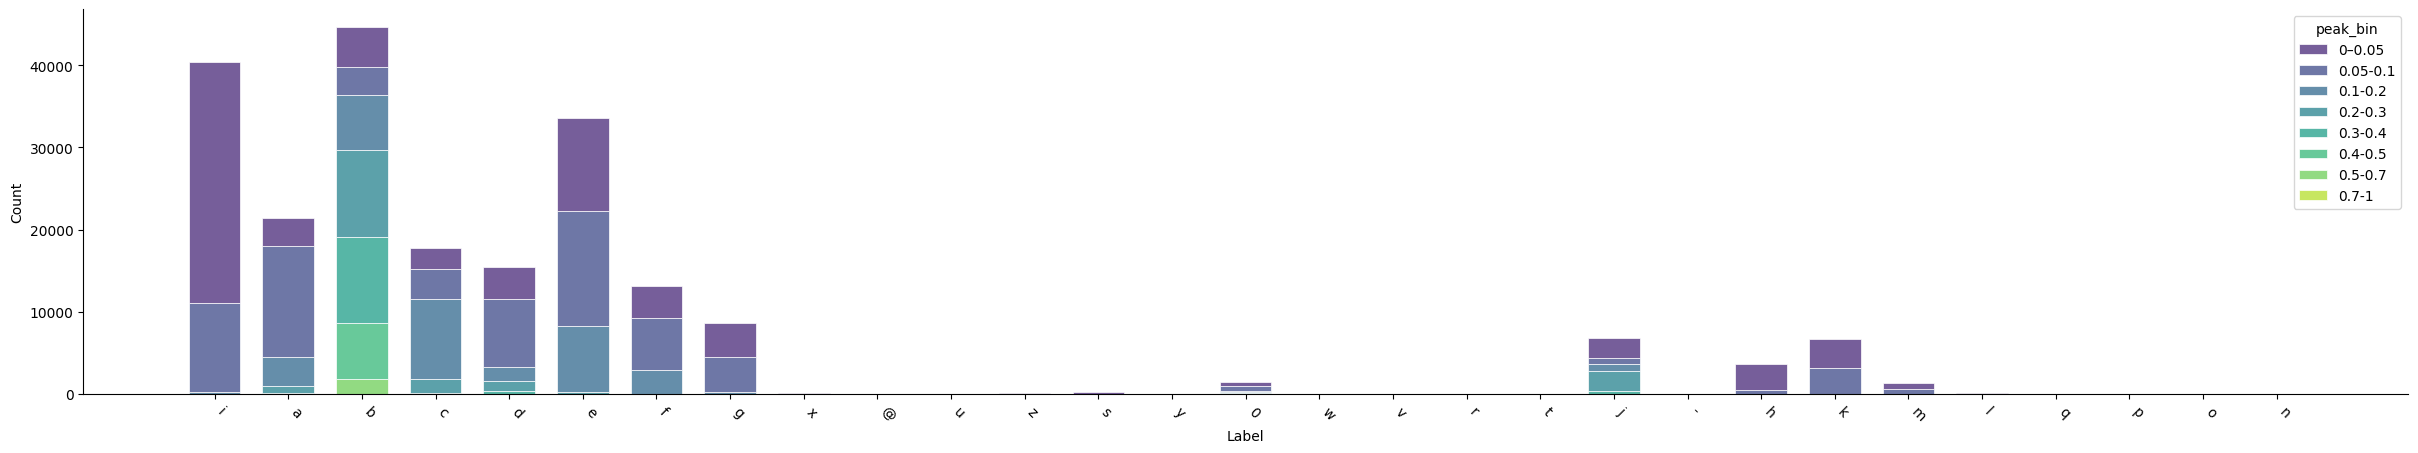

In [ ]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    selections_df,
    x="Label",
    multiple="stack",
    hue="peak_bin",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
    shrink=.7
)
plt.xticks(rotation=-45, ha='left')
plt.plot()

In [ ]:
selections_df = selections_df[
    (selections_df["peak"] >= 0.03) & 
    (selections_df["peak"] <= 0.975) ]

[]

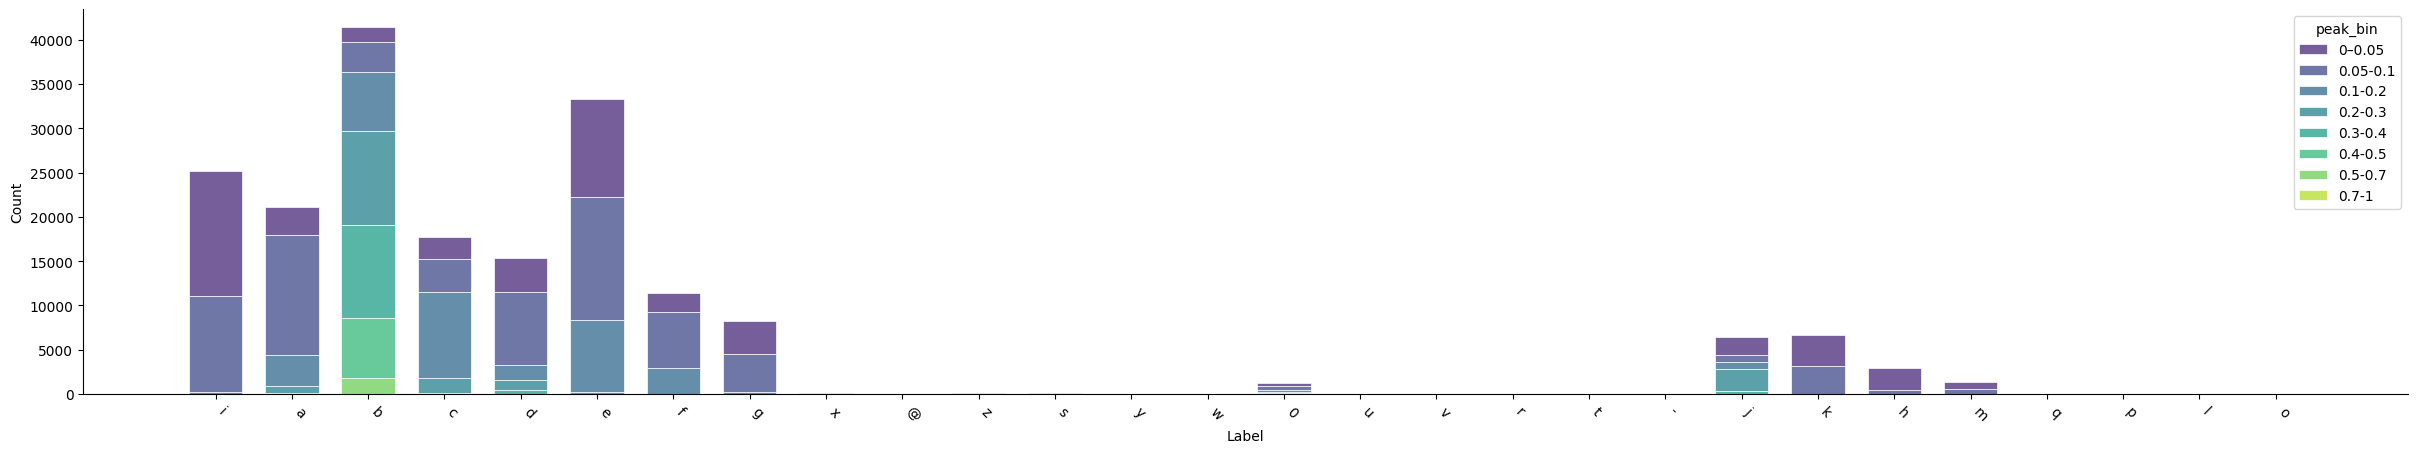

In [ ]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    selections_df,
    x="Label",
    multiple="stack",
    hue="peak_bin",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
    shrink=.7
)
plt.xticks(rotation=-45, ha='left')
plt.plot()

In [ ]:
selections_df.groupby('Label')['Clip ID'].count()

Label
-        5
0     1233
@        3
a    21096
b    41397
c    17728
d    15341
e    33317
f    11382
g     8244
h     2965
i    25232
j     6423
k     6618
l       14
m     1353
o        1
p        4
q       20
r        5
s      139
t       27
u       21
v       14
w        5
x      105
y        6
z       62
Name: Clip ID, dtype: int64

In [ ]:
label_counts = selections_df["Label"].value_counts()

# Keep only labels that occur at least 500 times
valid_labels = label_counts[label_counts >= 500].index
filtered_df = selections_df[selections_df["Label"].isin(valid_labels)].reset_index(drop=True)

In [ ]:
filtered_df.groupby('Label')['Clip ID'].count()

Label
0     1233
a    21096
b    41397
c    17728
d    15341
e    33317
f    11382
g     8244
h     2965
i    25232
j     6423
k     6618
m     1353
Name: Clip ID, dtype: int64

In [ ]:
# batch_plot_all_spectrograms(selections_df, per_page=25, ncols=5, with_borders=False, show=True, save_dir="spectrograms_bengalese_finch", window_length=1024)

In [ ]:
# randomly sample 10% of each class
df_subsampled = (
    filtered_df.groupby("Label", group_keys=False)
      .apply(lambda x: x.sample(frac=0.1, random_state=42))
)

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_27085/370138841.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.1, random_state=42))


In [ ]:
lfccs = Parallel(n_jobs=-1, verbose=10)(
    delayed(cepstral_coefficients)(
        row["clip_signal"],
        row["sr"],
        filterbank_type="linear"
    )
    for _, row in df_subsampled.iterrows()
)

df_subsampled["lfccs"] = lfccs

Python(27287) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
Python(27290) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27295) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27296) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27301) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27303) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27307) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27321) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27323) MallocStackLogging: can't t

In [ ]:
def process_row(row):
    try:
        features = extract_all_features(row["clip_signal"], row["sr"])
        features["Clip ID"] = row["Clip ID"]
        return features
    except Exception as e:
        print(f"Failed to process {row['Clip ID']}: {e}")
        return None

# Parallel processing
feature_rows = Parallel(n_jobs=-1, verbose=10)(
    delayed(process_row)(row) for _, row in df_subsampled.iterrows()
)

# Drop failed ones
feature_rows = [f for f in feature_rows if f is not None]

out_df = pd.DataFrame(feature_rows)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1914728376270036s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08495306968688965s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 148 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17679619789123535s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    2.4s
[Parallel(n_jobs

In [ ]:
merged_df = pd.merge(
    df_subsampled,
    out_df,
    on="Clip ID",
    how="left"
)

In [ ]:
merged_df.head()

,Begin Time (s),End Time (s),Label,Trackpath,Clip ID,clip_spectrogram,sr,hop_length,clip_signal,peak,...,spectral_skew,spectral_kurtosis,peak_frequency,spectrotemporal_entropy,dominant_freqs,mean_dom,min_dom,max_dom,range_dom,mod_dom
0,70.664381,70.779683,0,/Users/lena/Desktop/Master/Thesis/geese/code/W...,bl26lb16_200412_0908.32547.wav_43,"([[0.12857097, 0.1967371, 0.30077723, 0.357895...",32000.0,102.0,"[-0.09763647, -0.09200901, -0.100731574, -0.09...",0.108463,...,1.000297,3.062885,76.738609,0.428880,"[2937.5, 62.5, 62.5, 250.0, 62.5, 62.5, 62.5, ...",302.884615,62.5,2937.5,2875.0,1.173913
1,253.969687,254.002906,0,/Users/lena/Desktop/Master/Thesis/geese/code/W...,bl26lb16_200412_0908.32547.wav_247,"([[0.22544613, 0.17236066, 0.16760106, 0.19471...",32000.0,102.0,"[-0.0632137, -0.06402936, -0.06871941, -0.0705...",0.149663,...,2.226384,10.791718,3123.336291,0.522123,"[4625.0, 3125.0, 4250.0]",4000.000000,3125.0,4625.0,1500.0,1.750000
2,8.478344,8.637625,0,/Users/lena/Desktop/Master/Thesis/geese/code/W...,gr41rd51__3part_SYLc_th4191_belowhits_200612_0...,"([[0.33147398, 0.40807265, 0.45797384, 0.39934...",32000.0,102.0,"[0.21326077, 0.21622959, 0.22859971, 0.2177140...",0.061678,...,0.866854,3.096673,55.803139,0.567015,"[62.5, 2125.0, 1500.0, 1562.5, 1562.5, 1562.5,...",766.447368,62.5,2312.5,2250.0,5.222222
3,15.284656,15.446438,0,/Users/lena/Desktop/Master/Thesis/geese/code/W...,bl26lb16_200412_1553.14.wav_29,"([[0.065637395, 0.08593203, 0.09587924, 0.0866...",32000.0,102.0,"[0.027471239, 0.031462785, 0.023244893, 0.0133...",0.129978,...,1.176616,3.026942,67.162755,0.339745,"[375.0, 62.5, 3000.0, 125.0, 62.5, 62.5, 62.5,...",332.031250,62.5,3000.0,2937.5,2.574468
4,4.049125,4.215781,0,/Users/lena/Desktop/Master/Thesis/geese/code/W...,gr41rd51__3part_SYLc_th4191_belowhits_190612_1...,"([[0.056830768, 0.05286831, 0.05000068, 0.0465...",32000.0,102.0,"[0.03349086, 0.038422026, 0.03698377, 0.029587...",0.137181,...,1.219205,6.015809,4232.678770,0.413716,"[62.5, 2375.0, 2000.0, 1375.0, 62.5, 2437.5, 1...",1587.500000,62.5,4250.0,4187.5,5.134328


In [ ]:
filtered_by_percentile = merged_df.loc[merged_df["duration"] >= np.quantile(merged_df["duration"], 0.9992)]
# take the shortest call among those long calls
longest_call_quantile = filtered_by_percentile.loc[filtered_by_percentile["duration"].idxmin()]

max_bins_spectro = longest_call_quantile["clip_spectrogram"][0].shape[1]
max_bins_lfcc = longest_call_quantile["lfccs"].shape[1]

In [ ]:
# Apply transformation to each spectrogram
def process_spectrogram(s_tuple, target_bins_total):
    return rescale_and_pad(s_tuple[0], target_bins_total)

padded_spectrograms = Parallel(n_jobs=-1, verbose=10)(
    delayed(process_spectrogram)(s_tuple, max_bins_spectro) 
    for s_tuple in merged_df["clip_spectrogram"]
)

merged_df["padded_spectrogram"] = padded_spectrograms

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.03037881851196289s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0983421802520752s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1020650863647461s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.14525985717773438s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 360 tasks      |

In [ ]:
# Apply transformation to lfccs
def process_lfcc(lfccs, target_bins_total):
    return rescale_and_pad(lfccs, target_bins_total)

padded_lfccs = Parallel(n_jobs=-1, verbose=10)(
    delayed(process_lfcc)(lfcc_matrix, max_bins_lfcc) 
    for lfcc_matrix in merged_df["lfccs"]
)

merged_df["padded_lfccs"] = padded_lfccs

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.007756948471069336s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.06660628318786621s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.045831918716430664s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.059938907623291016s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 360 tasks  

[]

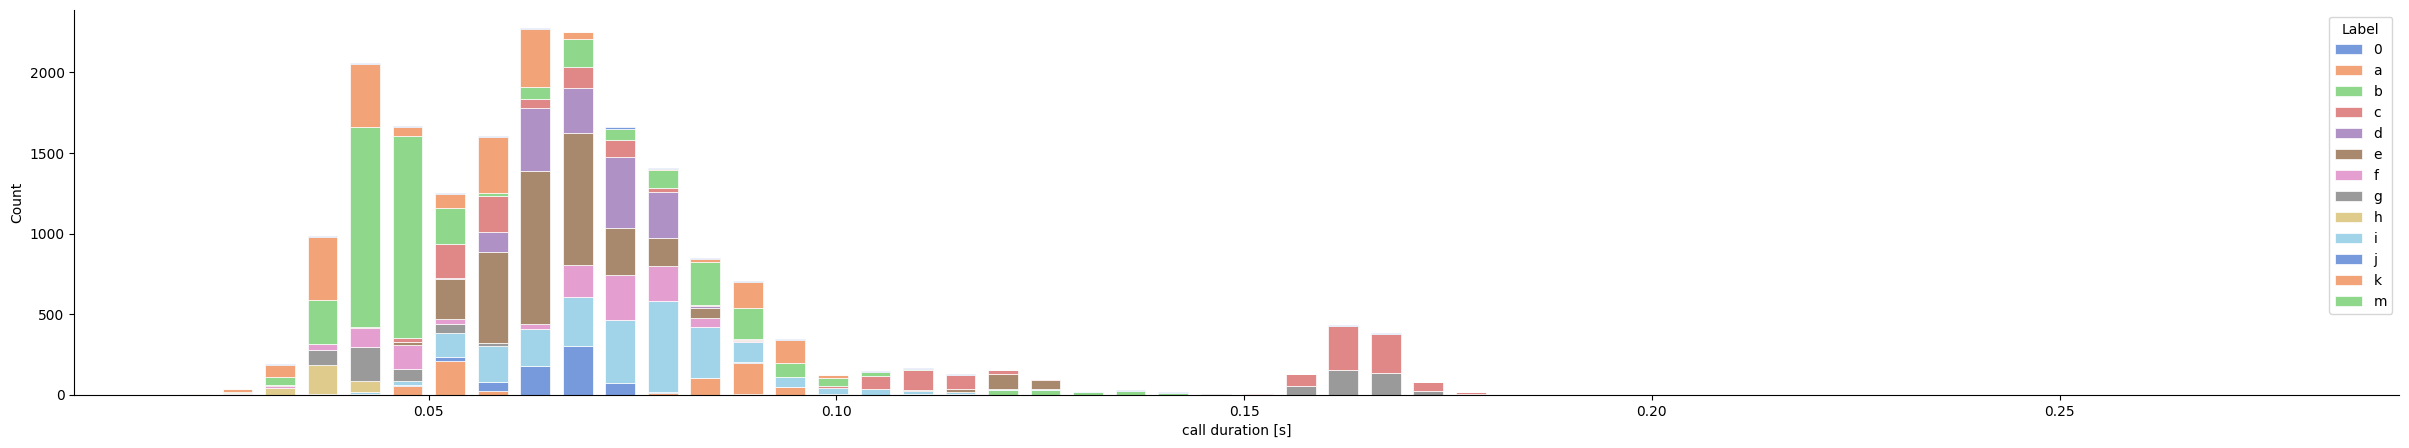

In [ ]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

sns.histplot(
    merged_df,
    x="duration",
    multiple="stack",
    hue="Label",
    palette="muted",
    edgecolor="1",
    linewidth=.5,
    shrink=.7,
    bins=50,
)
ax.set_xlabel("call duration [s]")
plt.plot()

[]

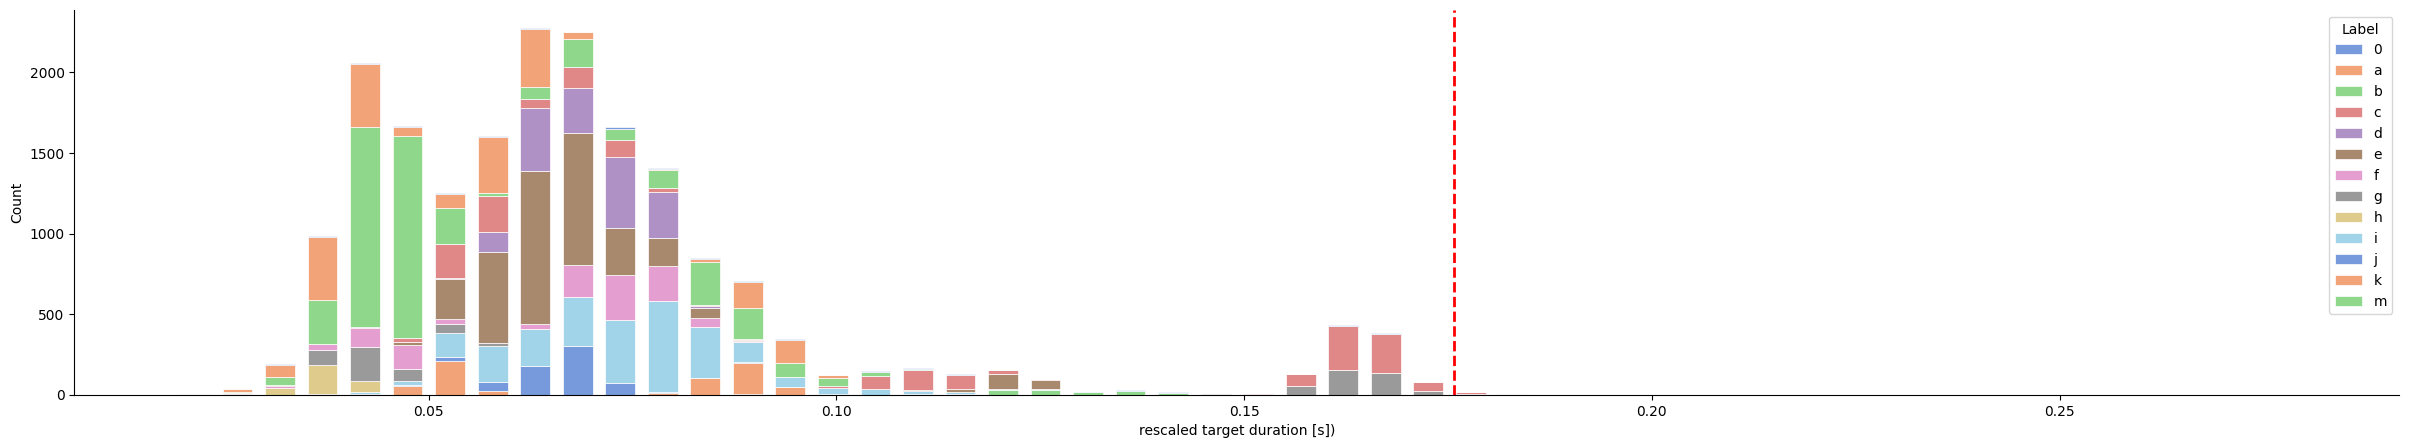

In [ ]:
f, ax = plt.subplots(figsize=(30, 5))
sns.despine(f)

histplot = sns.histplot(
    merged_df,
    x="duration",
    multiple="stack",
    hue="Label",
    palette="muted",
    edgecolor="1",
    linewidth=.5,
    shrink=.7,
    bins=50,
    ax=ax
)
ax.set_xlabel("rescaled target duration [s])")

quantile = np.quantile(merged_df["duration"], 0.9992)
filtered_by_percentile = merged_df.loc[merged_df["duration"] >= quantile]
longest_call_quantile = filtered_by_percentile.loc[filtered_by_percentile["duration"].idxmin()]

ax.axvline(longest_call_quantile["duration"], color='red', linestyle='--', linewidth=2, label=f'99th Percentile: {longest_call_quantile["duration"]:.2f}')


plt.plot()

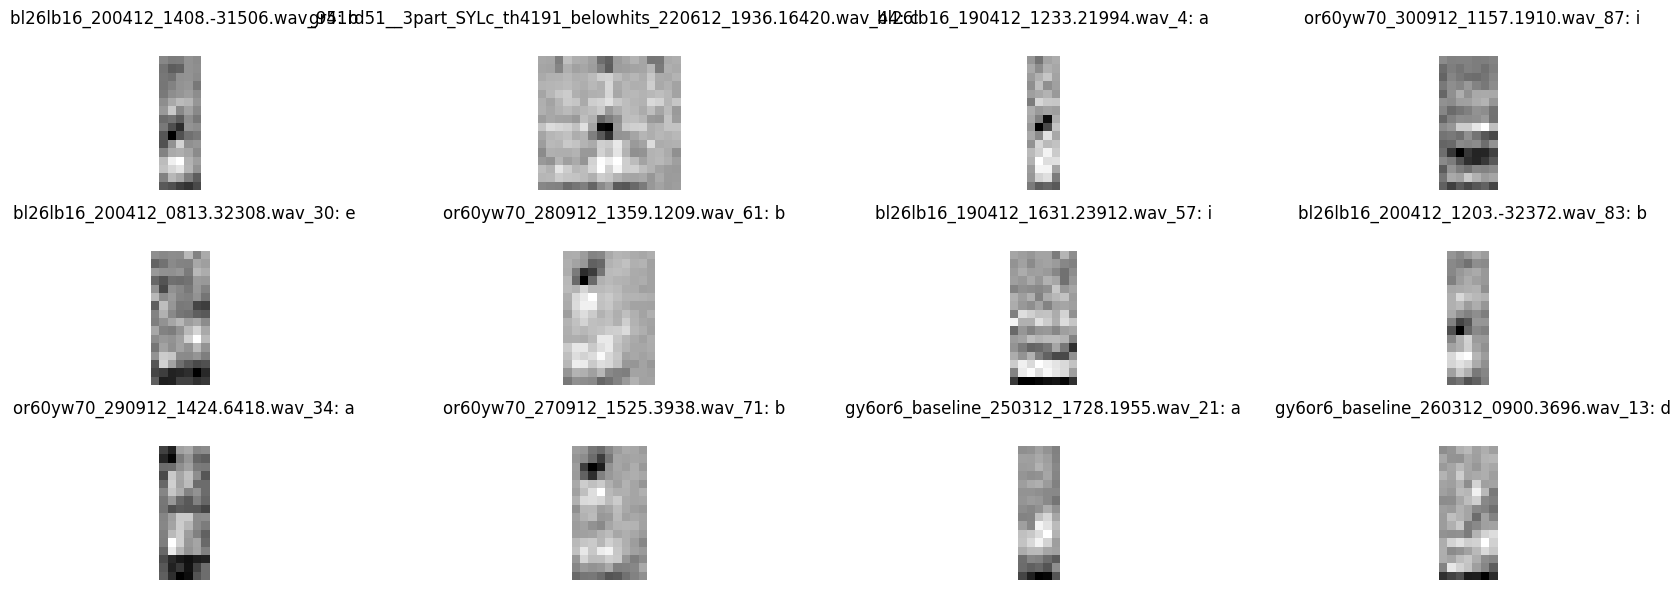

In [ ]:
# plot random sample of 8 calls, linearly scaled and padded
sample_calls = merged_df.sample(n=12, random_state=2300)

fig, axes = plt.subplots(3, 4, figsize=(19, 6))

for i, (_, vocalization) in enumerate(sample_calls.iterrows()):
  row = i // 4
  col = i % 4
  axes[row, col].matshow(vocalization["padded_lfccs"], origin="lower", cmap="binary")
  axes[row, col].set_title(f'{vocalization["Clip ID"]}: {vocalization["Label"]}', )
  axes[row, col].axis("off") 
    
for i in range(len(sample_calls), 8):
  row = i // 4
  col = i % 4
  axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
longest_call_quantile["lfccs"].shape[1]

18

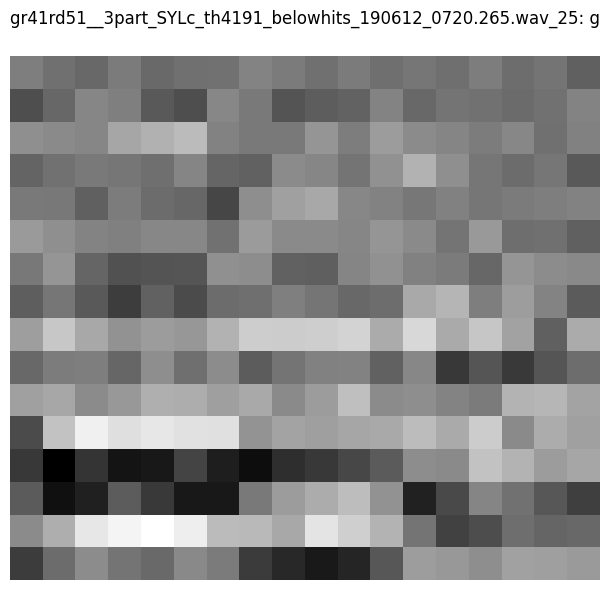

In [ ]:
fig, ax = plt.subplots(figsize=(19, 6))

ax.matshow(longest_call_quantile["padded_lfccs"], origin="lower", cmap="binary")
ax.set_title(f'{longest_call_quantile["Clip ID"]}: {longest_call_quantile["Label"]}', )
ax.axis("off") 

plt.tight_layout()
plt.show()

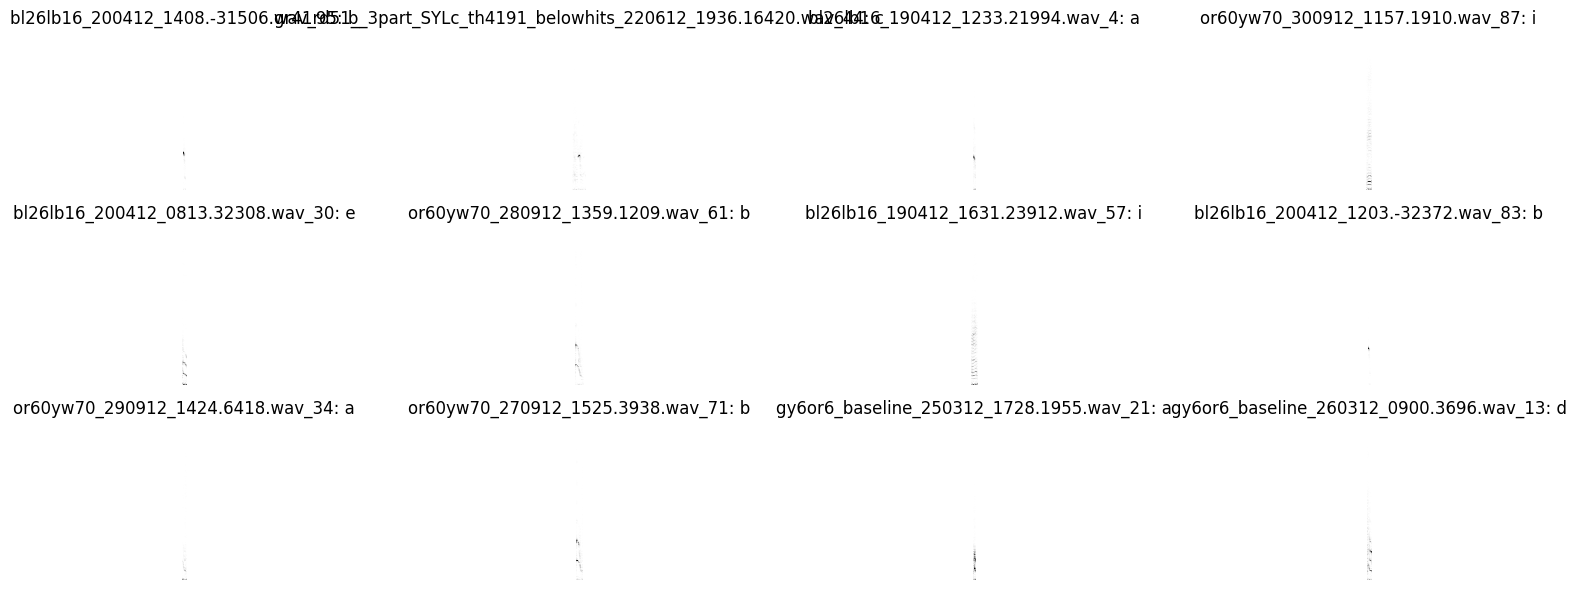

In [ ]:
# plot random sample of 8 calls, linearly scaled and padded
sample_calls = merged_df.sample(n=12, random_state=2300)

# plot first 8 calls
#sample_calls = calls_df.iloc[:8]

fig, axes = plt.subplots(3, 4, figsize=(19, 6))

for i, (_, vocalization) in enumerate(sample_calls.iterrows()):
  row = i // 4
  col = i % 4
  axes[row, col].matshow(vocalization["padded_spectrogram"], origin="lower", cmap="binary")
  axes[row, col].set_title(f'{vocalization["Clip ID"]}: {vocalization["Label"]}', )
  axes[row, col].axis("off") 
    
for i in range(len(sample_calls), 8):
  row = i // 4
  col = i % 4
  axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
columns_to_drop = [
    "clip_signal_trimmed",
    "clip_signal_bounds",
    "clip_spectrogram_trimmed",
    "same_track",
    "log_target_duration",
    "normalized_log_length",
    "log_duration"
    ]
merged_df = merged_df.drop(columns=columns_to_drop)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6639 entries, 0 to 6638
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Track ID                 6639 non-null   object 
 1   Clip ID                  6639 non-null   object 
 2   Goose ID                 6639 non-null   object 
 3   Location                 6639 non-null   object 
 4   Day                      6639 non-null   float64
 5   Month                    6639 non-null   float64
 6   Year                     6639 non-null   float64
 7   Date                     1016 non-null   object 
 8   Time                     6634 non-null   object 
 9   Recorder                 615 non-null    object 
 10  Microphone               6638 non-null   object 
 11  Comment                  996 non-null    object 
 12  Context                  344 non-null    object 
 13  Recorder ID              6639 non-null   object 
 14  Begin Time (s)          

In [ ]:
merged_df.to_pickle("features.pkl")

: 